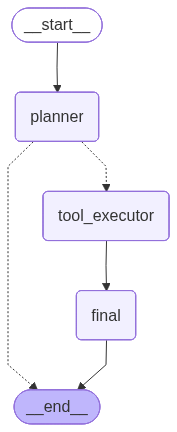

================================== Ai Message ==================================

Hello! How can I help today? I can:

- Pull photography tips from popular books
- Extract EXIF data from an image
- Generate a caption for an image
- Score the aesthetic quality of a photo

If you have an photo, you can upload it and I can analyze it or caption it. Or tell me what you’re looking to learn (composition, lighting, editing, etc.), and I’ll tailor tips for you.


In [2]:
from dotenv import load_dotenv
from PIL import Image
from tools.models_utils import score_aesthetic
from tools.exif_tool import fetch_exif
from tools.captioning_tool import caption_image
from rag.retriever_fetch_tool import retrieve_photography_tips
from agent.agent_state import ToolCalls
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

load_dotenv()

# pil_img = Image.open("data\DSCF0677.JPG").convert("RGB")
# aesthetic_scorer = score_aesthetic_tool
# probs, mean_score = aesthetic_scorer.invoke({"pil_img": pil_img})
# print(probs)
# print(mean_score)

retrieve_photography_tips_tool = retrieve_photography_tips
score_aesthetic_tool = score_aesthetic
fetch_exif_tool = fetch_exif
captioning_tool = caption_image
tools = [retrieve_photography_tips_tool, score_aesthetic_tool, fetch_exif_tool, captioning_tool]

response_model = init_chat_model("gpt-5-nano", temperature=0)

tool_decider_model = create_agent(
    model="gpt-5-nano",
    tools=tools,
    response_format=ToolCalls
)

from IPython.display import Image, display

from agent.graph import build_graph
graph = build_graph(tool_decider_model, response_model)

display(Image(graph.get_graph().draw_mermaid_png()))

def generate_query_or_respond(state: MessagesState):
    """Call the model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    response = (
        response_model
        .bind_tools(tools).invoke(state["messages"])  
    )
    return {"messages": [response]}

input = {"messages": [{"role": "user", "content": "hello!"}]}
generate_query_or_respond(input)["messages"][-1].pretty_print()